In [1]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving cleaned_comments.csv to cleaned_comments.csv


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility modules
import re
import ast
from collections import Counter
from itertools import combinations, cycle

In [3]:
# Load data
df = pd.read_csv('cleaned_comments.csv')

# Inspect first few rows
print(df.head())

# If tokens are stored as strings like "['a','b']", convert to Python lists
if isinstance(df["cleaned_tokens"].iloc[0], str):
    df["cleaned_tokens"] = df["cleaned_tokens"].apply(ast.literal_eval)

# Quick sanity checks
print("Rows:", len(df))
print("Sample tokens:", df["cleaned_tokens"].iloc[0][:10])

              username             timestamp  likes  \
0       LafonClark-r3r  2026-01-24T17:41:22Z      0   
1    MahboobaliAli-i5l  2026-01-23T14:29:07Z      0   
2       Blackwhite2277  2026-01-22T21:27:44Z      0   
3             stamdar1  2026-01-22T17:27:42Z      0   
4  DhivyabharathiB-t3v  2026-01-22T04:26:38Z      0   

                                        comment_text  \
0  Post Quantum Polymorphic Prompt Injection Via ...   
1              Absolute perfection, what a tutorial!   
2  If we are allowing AI to do EVERYTHING, only a...   
3     honestly so impressed by him writing backwards   
4                      Informative.. Clear Info sir.   

                                      cleaned_tokens  tok_len  char_len  \
0  ['post', 'quantum', 'polymorphic', 'prompt', '...       16       123   
1             ['absolute', 'perfection', 'tutorial']        3        37   
2  ['allowing', 'everything', 'elite', 'group', '...       15       204   
3  ['honestly', 'impressed', 'wr

In [4]:
# Create Chunks
chunks = np.array_split(df, 5)
for i, ch in enumerate(chunks, 1):
    print(f"Chunk {i}: {len(ch)} rows")

Chunk 1: 44 rows
Chunk 2: 43 rows
Chunk 3: 43 rows
Chunk 4: 43 rows
Chunk 5: 43 rows


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [5]:
# Helper function for Barplot and Dataframe

# Ensure tokens are lists in every chunk
for i in range(len(chunks)):
    if isinstance(chunks[i]["cleaned_tokens"].iloc[0], str):
        chunks[i]["cleaned_tokens"] = chunks[i]["cleaned_tokens"].apply(ast.literal_eval)

# Helper functions
def get_unigram_counts(chunk):
    tx = chunk["cleaned_tokens"].tolist()
    return Counter(t for row in tx for t in row)

def get_bigram_counts(chunk):
    tx = chunk["cleaned_tokens"].tolist()
    c = Counter()
    for row in tx:
        # co-occurring unordered pairs within a comment
        c.update(combinations(sorted(set(row)), 2))
    return c

# Count unigrams and bigrams for each chunk
uni_counts = [get_unigram_counts(ch) for ch in chunks]
bi_counts  = [get_bigram_counts(ch)  for ch in chunks]

# Determine top 10 global terms for consistent comparison
total_uni = sum(uni_counts, Counter())
top10_uni_terms = [w for w, _ in total_uni.most_common(10)]

total_bi = sum(bi_counts, Counter())
top10_bi_pairs = [p for p, _ in total_bi.most_common(10)]

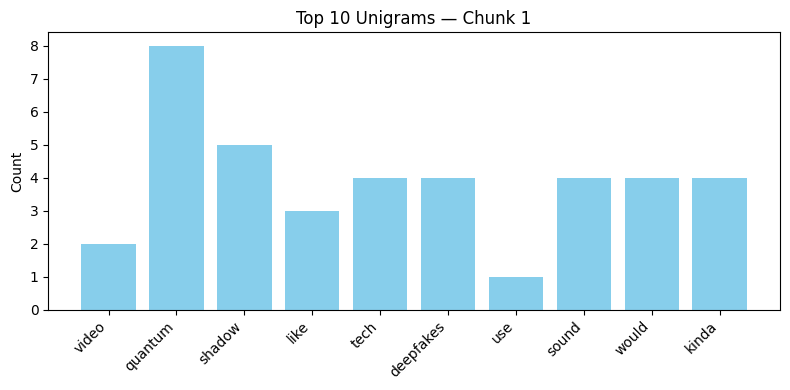

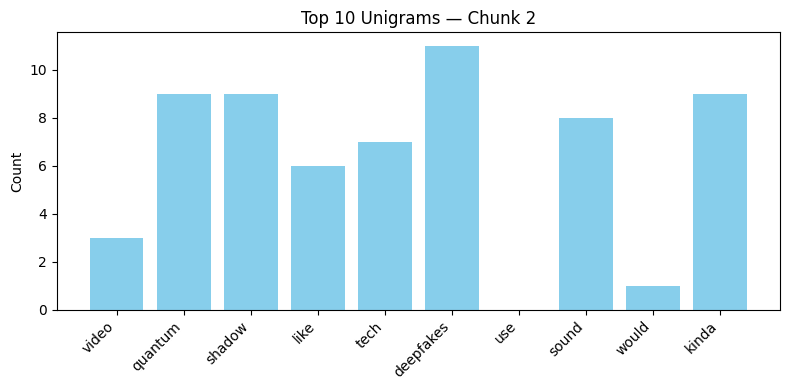

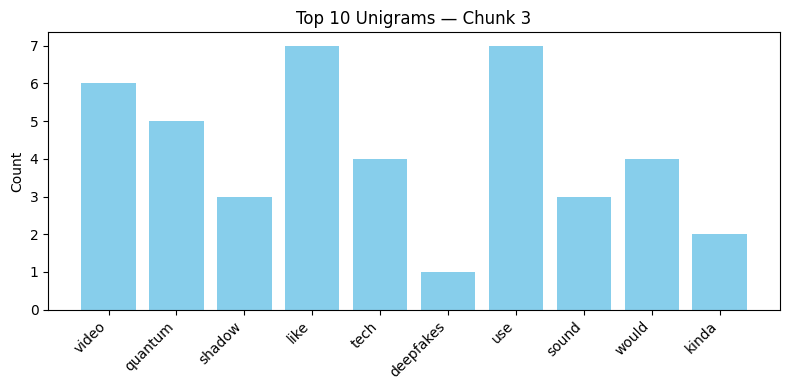

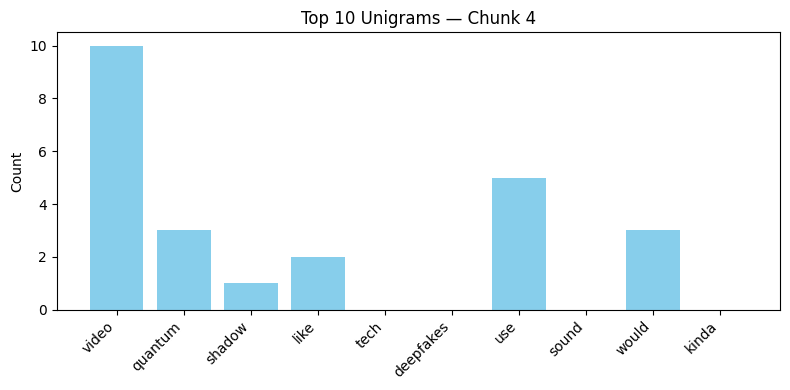

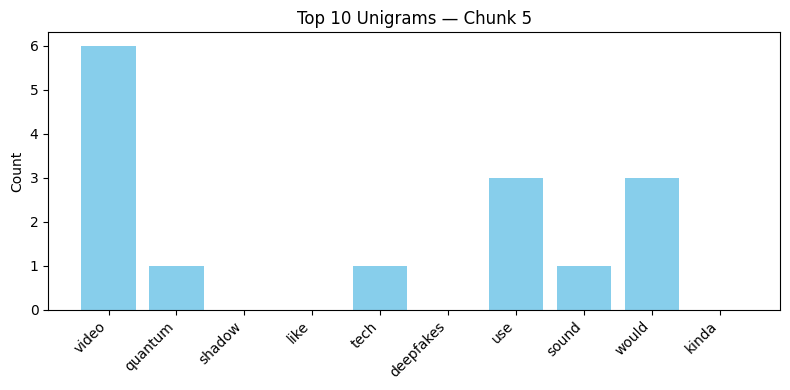

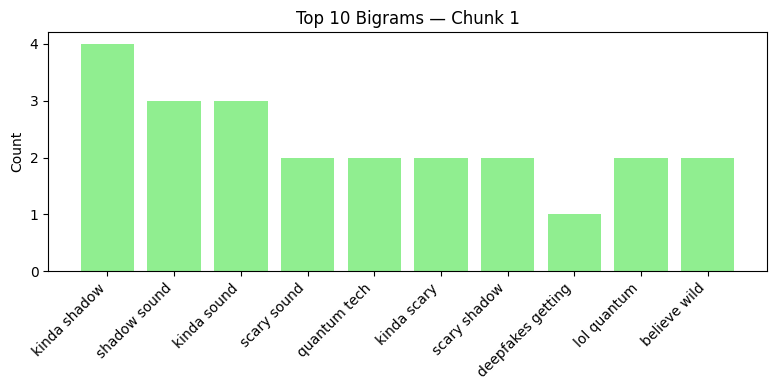

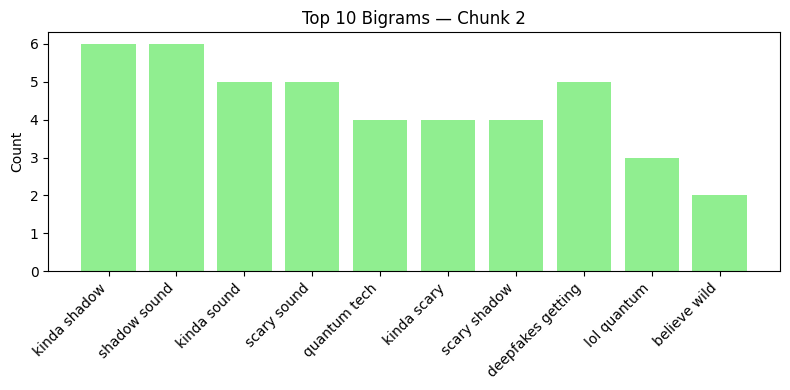

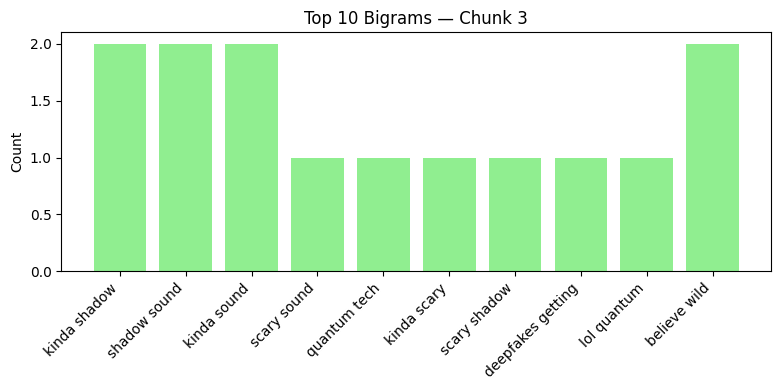

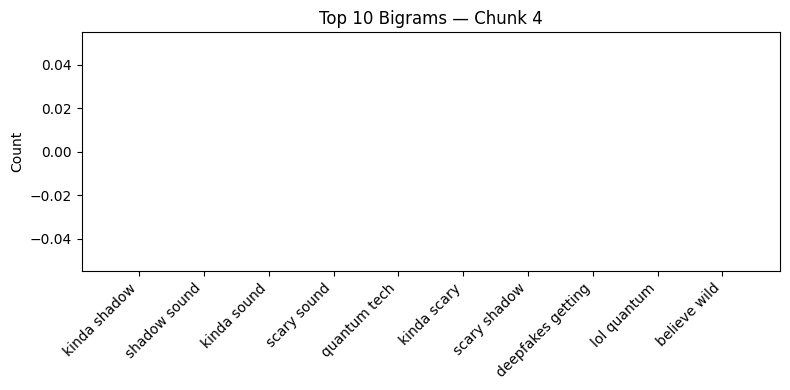

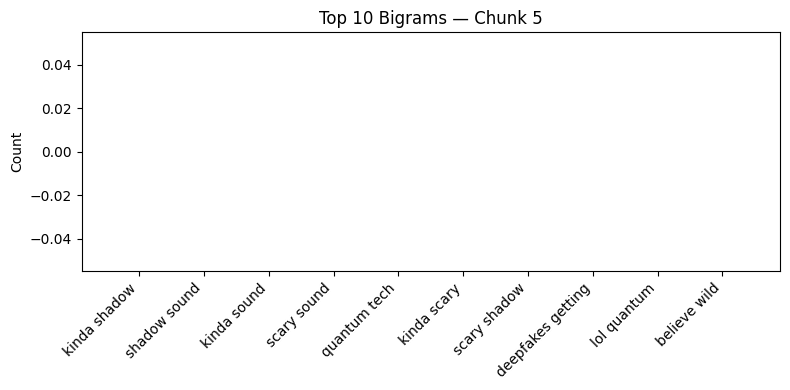

In [6]:
# Plot Unigram Bar Charts
for i in range(5):
    counts = [uni_counts[i].get(w, 0) for w in top10_uni_terms]
    plt.figure(figsize=(8, 4))
    plt.bar(top10_uni_terms, counts, color="skyblue")
    plt.title(f"Top 10 Unigrams — Chunk {i+1}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Plot Bigram Bar Charts
bi_labels = [f"{p[0]} {p[1]}" for p in top10_bi_pairs]
for i in range(5):
    counts = [bi_counts[i].get(p, 0) for p in top10_bi_pairs]
    plt.figure(figsize=(8, 4))
    plt.bar(bi_labels, counts, color="lightgreen")
    plt.title(f"Top 10 Bigrams — Chunk {i+1}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [7]:
# UNIGRAM tracking table
uni_table = pd.DataFrame({
    "Pattern": top10_uni_terms,
    "Chunk 1": [uni_counts[0].get(w, 0) for w in top10_uni_terms],
    "Chunk 2": [uni_counts[1].get(w, 0) for w in top10_uni_terms],
    "Chunk 3": [uni_counts[2].get(w, 0) for w in top10_uni_terms],
    "Chunk 4": [uni_counts[3].get(w, 0) for w in top10_uni_terms],
    "Chunk 5": [uni_counts[4].get(w, 0) for w in top10_uni_terms],
})

print("UNIGRAM Tracking Table (Top 10):")
display(uni_table)

# BIGRAM tracking table
bi_table = pd.DataFrame({
    "Pattern": [f"({p[0]}, {p[1]})" for p in top10_bi_pairs],
    "Chunk 1": [bi_counts[0].get(p, 0) for p in top10_bi_pairs],
    "Chunk 2": [bi_counts[1].get(p, 0) for p in top10_bi_pairs],
    "Chunk 3": [bi_counts[2].get(p, 0) for p in top10_bi_pairs],
    "Chunk 4": [bi_counts[3].get(p, 0) for p in top10_bi_pairs],
    "Chunk 5": [bi_counts[4].get(p, 0) for p in top10_bi_pairs],
})

print("BIGRAM Tracking Table (Top 10):")
display(bi_table)

UNIGRAM Tracking Table (Top 10):


,Pattern,Chunk 1,Chunk 2,Chunk 3,Chunk 4,Chunk 5
0,video,2,3,6,10,6
1,quantum,8,9,5,3,1
2,shadow,5,9,3,1,0
3,like,3,6,7,2,0
4,tech,4,7,4,0,1
5,deepfakes,4,11,1,0,0
6,use,1,0,7,5,3
7,sound,4,8,3,0,1
8,would,4,1,4,3,3
9,kinda,4,9,2,0,0


BIGRAM Tracking Table (Top 10):


,Pattern,Chunk 1,Chunk 2,Chunk 3,Chunk 4,Chunk 5
0,"(kinda, shadow)",4,6,2,0,0
1,"(shadow, sound)",3,6,2,0,0
2,"(kinda, sound)",3,5,2,0,0
3,"(scary, sound)",2,5,1,0,0
4,"(quantum, tech)",2,4,1,0,0
5,"(kinda, scary)",2,4,1,0,0
6,"(scary, shadow)",2,4,1,0,0
7,"(deepfakes, getting)",1,5,1,0,0
8,"(lol, quantum)",2,3,1,0,0
9,"(believe, wild)",2,2,2,0,0


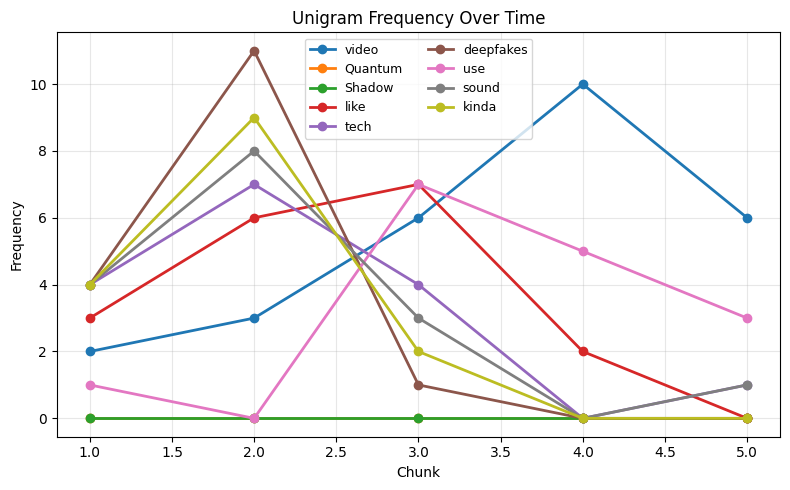

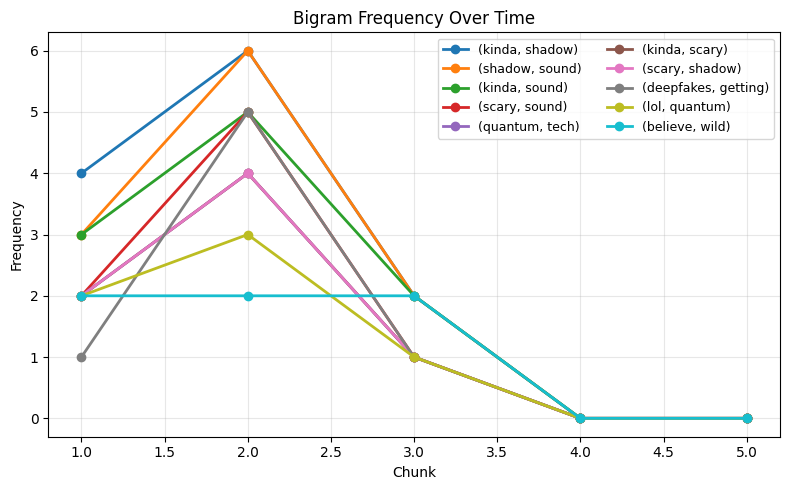

In [10]:
# Selected unigrams and bigrams
selected_unigrams = ["video","Quantum","Shadow","like","tech","deepfakes","use","sound","kinda"]
selected_bigrams  = ["(kinda, shadow)", "(shadow, sound)", "(kinda, sound)", "(scary, sound)",
                     "(quantum, tech)", "(kinda, scary)", "(scary, shadow)", "(deepfakes, getting)",
                     "(lol, quantum)", "(believe, wild)"]


# Get unigram counts for each chunk
def unigram_series(token):
    return [uni_counts[i].get(token, 0) for i in range(5)]

# Convert bigram string to tuple
def parse_bigram_label(label):
    m = re.match(r"\(\s*([^,]+)\s*,\s*([^)]+)\s*\)", label)
    if not m:
        raise ValueError(f"Bad bigram label: {label}")
    a, b = m.group(1).strip(), m.group(2).strip()
    return tuple(sorted([a, b]))

# Get bigram counts for each chunk
def bigram_series(label):
    pair = parse_bigram_label(label)
    return [bi_counts[i].get(pair, 0) for i in range(5)]

# Create frequency tables
uni_freq_df = pd.DataFrame({u: unigram_series(u) for u in selected_unigrams}, index=[1,2,3,4,5])
uni_freq_df.index.name = "Chunk"

bi_freq_df = pd.DataFrame({b: bigram_series(b) for b in selected_bigrams}, index=[1,2,3,4,5])
bi_freq_df.index.name = "Chunk"

# Plot Unigrams
plt.figure(figsize=(8,5))
for col in uni_freq_df.columns:
    plt.plot(uni_freq_df.index, uni_freq_df[col], marker='o', markersize=6, linewidth=2, label=col)
plt.xlabel("Chunk")
plt.ylabel("Frequency")
plt.title("Unigram Frequency Over Time")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Plot Bigrams
plt.figure(figsize=(8,5))
for col in bi_freq_df.columns:
    plt.plot(bi_freq_df.index, bi_freq_df[col], marker='o', markersize=6, linewidth=2, label=col)
plt.xlabel("Chunk")
plt.ylabel("Frequency")
plt.title("Bigram Frequency Over Time")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


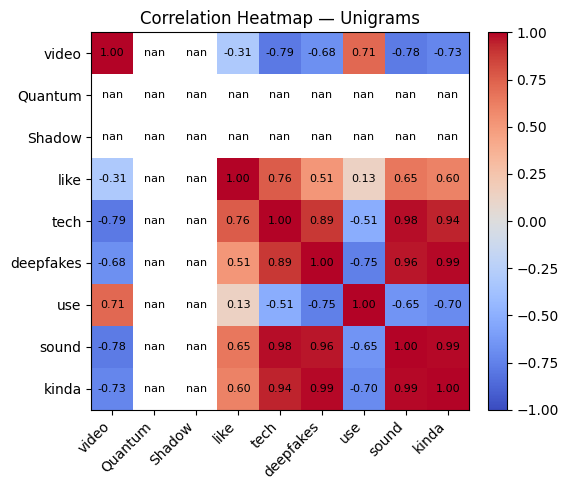

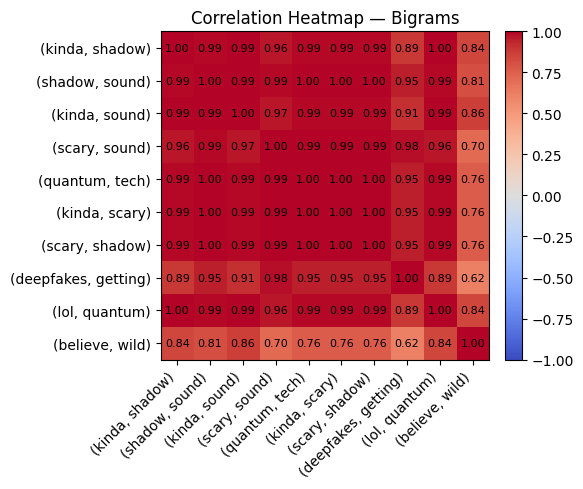

In [11]:
# Compute correlation matrices
corr_uni = uni_freq_df.corr()
corr_bi  = bi_freq_df.corr()

# Unigram Heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(corr_uni, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation Heatmap — Unigrams")
plt.xticks(range(len(corr_uni.columns)), corr_uni.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_uni.index)), corr_uni.index)
for i in range(len(corr_uni)):
    for j in range(len(corr_uni)):
        plt.text(j, i, f"{corr_uni.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Bigram Heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(corr_bi, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation Heatmap — Bigrams")
plt.xticks(range(len(corr_bi.columns)), corr_bi.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_bi.index)), corr_bi.index)
for i in range(len(corr_bi)):
    for j in range(len(corr_bi)):
        plt.text(j, i, f"{corr_bi.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()